# NUTS Backends — `pymc` vs `numpyro` vs `nutpie`

`BayesianMMM` has **two independent** inference choices, and they are easy to
confuse:

| Axis | Set by | Question it answers | Notebook |
|---|---|---|---|
| **Fit method** | `fit(method=...)` / `ModelConfig.fit_method` | *What* do we estimate — the exact posterior, or a fast approximation to it? | [`approximate_posteriors.ipynb`](approximate_posteriors.ipynb) |
| **NUTS backend** | `ModelConfig.inference_method` / `fit(nuts_sampler=...)` | *How* is the NUTS trajectory computed? | **this one** |

The first axis **changes the answer**: MAP gives a point, ADVI gives an
elliptical approximation, NUTS gives the posterior. The second axis **must
not**. All three backends below run the same No-U-Turn Sampler against the same
model graph and target the identical posterior. They differ only in the
machinery underneath:

| Backend | Enum | Implementation |
|---|---|---|
| `"pymc"` | `BAYESIAN_PYMC` | reference implementation, PyTensor-compiled gradients |
| `"numpyro"` | `BAYESIAN_NUMPYRO` | JAX — XLA-compiled, vectorises chains on one device |
| `"nutpie"` | `BAYESIAN_NUTPIE` | Rust sampler loop, PyTensor or Numba-compiled gradients |

So the only questions worth asking are: **do they agree?** (they must, or one is
broken) and **what does each cost?** This notebook measures both, on two model
sizes, rather than repeating folklore about which is fastest.

> **Version note.** Before **v1.2.0** the `nutpie` backend was unreachable —
> `nutpie` was a declared dependency, but sampler choice was a binary
> `use_numpyro` flag with no value that could select it. The same release made
> `ModelConfig.target_accept` reach `pm.sample` (§7) and added
> `fit(nuts_sampler=...)` to the core model.

## 0 — Setup

Silence the samplers' progress chatter so the measurements print cleanly. Note
we time with `perf_counter` around `fit()`, which includes **compilation** —
that is deliberate, and §5 separates it out.

In [1]:
import contextlib, logging, os, pathlib, sys, time, warnings

os.environ.setdefault("TQDM_DISABLE", "1")
warnings.filterwarnings("ignore")
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor", "nutpie"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))  # repo root (kernel cwd is demos/)

import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120,
})
INK, SKY, LEAF, BERRY, MUTED = "#2b2118", "#3b6ea5", "#3f7d5e", "#a63a50", "#8a8079"


@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    # Stream redirection alone is not enough: logging handlers bind their stream
    # at creation, so pymc's convergence notices bypass it. Disable logging for
    # the duration too -- we report R-hat / ESS / divergences ourselves.
    prev = logging.root.manager.disable
    logging.disable(logging.CRITICAL)
    try:
        with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
                contextlib.redirect_stderr(_dn):
            yield
    finally:
        logging.disable(prev)


from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType
from mmm_framework.synth import dgp, dgp_geo

BACKENDS = [
    ("pymc",    InferenceMethod.BAYESIAN_PYMC,    INK),
    ("numpyro", InferenceMethod.BAYESIAN_NUMPYRO, SKY),
    ("nutpie",  InferenceMethod.BAYESIAN_NUTPIE,  BERRY),
]
COLOR = {name: c for name, _, c in BACKENDS}
print("backends:", [b[0] for b in BACKENDS])

backends: ['pymc', 'numpyro', 'nutpie']


### The enum resolves to the `pm.sample` string

`ModelConfig.nuts_sampler` (added in v1.2.0) is the single place the inference
method is translated into the backend string. Note the last row: a
**frequentist** method reports `"pymc"` rather than raising — §8 returns to what
that means.

In [2]:
rows = [{"InferenceMethod": m.value, "is_bayesian": ModelConfig(inference_method=m).is_bayesian,
         "nuts_sampler": ModelConfig(inference_method=m).nuts_sampler}
        for m in InferenceMethod]
display(pd.DataFrame(rows))

,InferenceMethod,is_bayesian,nuts_sampler
0,bayesian_pymc,True,pymc
1,bayesian_numpyro,True,numpyro
2,bayesian_nutpie,True,nutpie
3,frequentist_ridge,False,pymc
4,frequentist_cvxpy,False,pymc


## 1 — The world and the model

`make_clean` draws data from the model's exact generative family (geometric
adstock, `1-exp(-λx)` saturation, additive, Gaussian noise). A **positive
control**: the model is not misspecified, so nothing below is contaminated by
the model being wrong. Four media channels, one control, three years weekly.

One helper fits the same model with a given backend and returns the metrics we
compare. It catches exceptions so one failing backend reports a row instead of
killing the notebook.

In [3]:
sc = dgp.make_clean(seed=0)
print(f"channels : {sc.channels}")
print(f"weeks    : {len(sc.y)}   controls: {list(sc.controls.columns)}")

DRAWS, TUNE, CHAINS = 1000, 1000, 4


def fit_once(scenario, method, *, draws=DRAWS, tune=TUNE, chains=CHAINS,
             seed=0, target_accept=None):
    "Fit once with one backend; return timing + diagnostics + the trace."
    cfg = ModelConfig(
        inference_method=method, n_chains=chains, n_draws=draws, n_tune=tune,
        use_parametric_adstock=True, optim_seed=seed,
        **({} if target_accept is None else {"target_accept": target_accept}),
    )
    model = BayesianMMM(scenario.panel(), cfg, TrendConfig(type=TrendType.LINEAR))
    t0 = time.perf_counter()
    try:
        with quiet():
            res = model.fit(random_seed=seed, progressbar=False)
    except Exception as exc:                      # a backend that cannot run here
        return {"ok": False, "secs": time.perf_counter() - t0,
                "error": f"{type(exc).__name__}: {exc}"[:120], "trace": None}
    secs = time.perf_counter() - t0
    trace = res.trace
    # Worst-mixing parameter among the ones we actually make decisions with.
    pars = [p for p in trace.posterior.data_vars
            if p.startswith(("beta_", "adstock_alpha_", "sat_lam_"))]
    ess = min(float(az.ess(trace, var_names=[p])[p].min()) for p in pars)
    return {"ok": True, "secs": secs, "ess_min": ess, "ess_per_s": ess / secs,
            "rhat": float(res.diagnostics["rhat_max"]),
            "div": int(res.diagnostics["divergences"]),
            "trace": trace, "n_pars": len(pars)}


print(f"config: draws={DRAWS} tune={TUNE} chains={CHAINS} "
      f"-> {DRAWS * CHAINS:,} nominal draws per fit")

channels : ['TV', 'Search', 'Social', 'Display']
weeks    : 156   controls: ['Price']
config: draws=1000 tune=1000 chains=4 -> 4,000 nominal draws per fit


## 2 — The naive benchmark: wall-clock

The obvious comparison, and the one most benchmarks stop at. Three repeats per
backend with different seeds, because a single timing on a laptop is nearly
meaningless — background load moves it more than the backend does.

In [4]:
REPEATS = 3
national = {}
for name, method, _ in BACKENDS:
    national[name] = [fit_once(sc, method, seed=r) for r in range(REPEATS)]
    ok = [f for f in national[name] if f["ok"]]
    secs = [f"{f['secs']:.1f}" for f in national[name]]
    print(f"{name:9} secs={secs}" + ("" if ok else "   <-- ALL FAILED"))

wall = pd.DataFrame({
    n: {"median s": np.median([f["secs"] for f in runs if f["ok"]]),
        "min s": min([f["secs"] for f in runs if f["ok"]], default=np.nan),
        "max s": max([f["secs"] for f in runs if f["ok"]], default=np.nan)}
    for n, runs in national.items()}).T
wall["spread %"] = 100 * (wall["max s"] - wall["min s"]) / wall["median s"]
display(wall.round(1))

pymc      secs=['12.5', '11.5', '11.5']


numpyro   secs=['11.3', '10.0', '10.1']


nutpie    secs=['11.8', '10.5', '10.9']


,median s,min s,max s,spread %
pymc,11.5,11.5,12.5,9.0
numpyro,10.1,10.0,11.3,12.9
nutpie,10.9,10.5,11.8,12.5


**Read the `spread %` column before the `median s` column.** The repeat-to-repeat
spread within a single backend is comparable to the gap *between* backends. On
this model, a stopwatch cannot tell these three apart — and any blog post
ranking them on one timed run each is reporting noise.

Wall-clock is also the wrong quantity in principle. A sampler that returns
10,000 highly autocorrelated draws in one second has told you less about the
posterior than one returning 500 near-independent draws in two.

## 3 — The right metric: effective samples per second

MCMC draws are correlated, so `n_draws` overstates how much information you
have. **Effective sample size** (ESS) is the equivalent number of *independent*
draws — it is what Monte Carlo error actually scales with
(`MCSE ≈ posterior_sd / sqrt(ESS)`). The currency of a sampler is therefore
**ESS per second**, and we take the *minimum* ESS across the parameters we make
decisions with (channel β, adstock α, saturation λ): a posterior is only as
trustworthy as its worst-mixing parameter.

,median s,min ESS,ESS/sec,R-hat max,divergences,ESS/draw
pymc,11.5,2397.0,196.9,1.0034,0.0,0.60
numpyro,10.1,1819.0,179.7,1.0037,0.0,0.45
nutpie,10.9,1100.0,105.1,1.0049,0.0,0.27


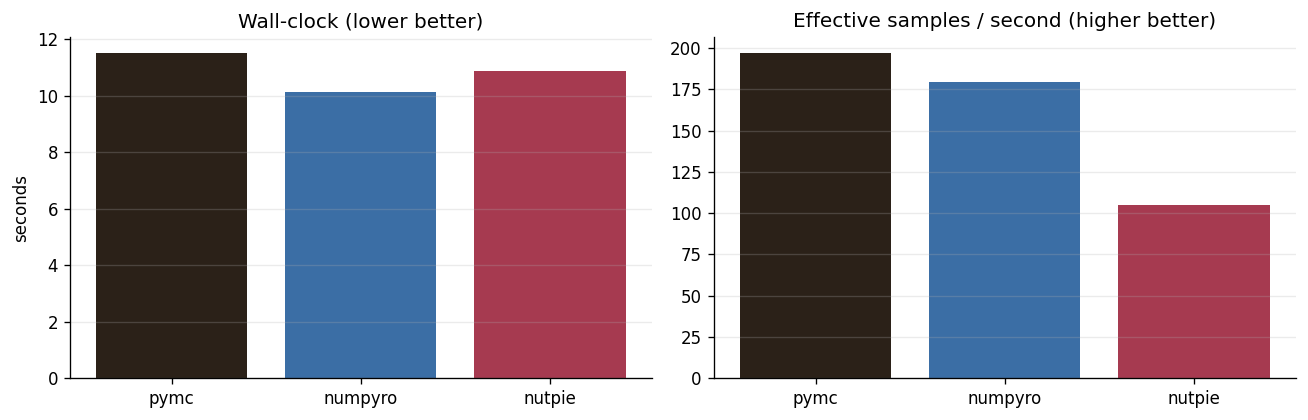

In [5]:
eff = pd.DataFrame({
    n: {"median s": np.median([f["secs"] for f in runs if f["ok"]]),
        "min ESS": np.median([f["ess_min"] for f in runs if f["ok"]]),
        "ESS/sec": np.median([f["ess_per_s"] for f in runs if f["ok"]]),
        "R-hat max": max([f["rhat"] for f in runs if f["ok"]], default=np.nan),
        "divergences": sum(f["div"] for f in runs if f["ok"])}
    for n, runs in national.items()}).T
eff["ESS/draw"] = eff["min ESS"] / (DRAWS * CHAINS)
display(eff.round({"median s": 1, "min ESS": 0, "ESS/sec": 1,
                   "R-hat max": 4, "divergences": 0, "ESS/draw": 2}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
names = list(eff.index)
axes[0].bar(names, eff["median s"], color=[COLOR[n] for n in names])
axes[0].set_title("Wall-clock (lower better)"); axes[0].set_ylabel("seconds")
axes[1].bar(names, eff["ESS/sec"], color=[COLOR[n] for n in names])
axes[1].set_title("Effective samples / second (higher better)")
for ax in axes:
    ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

The two panels do **not** tell the same story, and that is the point of the
notebook. Backends that look identical on wall-clock can differ substantially
per *effective* sample, because they adapt the step size and trajectory length
differently — same nominal draw count, different autocorrelation.

`ESS/draw` is the machine-independent version of the same number: what fraction
of each nominal draw is worth an independent one. Multiply by your own hardware's
draw rate to predict a different machine.

## 4 — Do they agree? (the check that actually matters)

Speed is irrelevant if the answer moves. All three are *exact* samplers
targeting one posterior, so their estimates must agree **to within Monte Carlo
error** — and the tolerance is not "close enough by eye", it is the MCSE.

For each channel β we take the pairwise difference between backends and divide
by the combined MCSE, `sqrt(mcse_a^2 + mcse_b^2)`. That is a z-score: |z| under
~3 is consistent with the backends sampling the same distribution, and a
systematically large |z| would mean one of them is wrong.

In [6]:
def beta_table(runs_by_backend, channels):
    "Posterior mean and MCSE of each beta, from the first successful run."
    out = {}
    for name, runs in runs_by_backend.items():
        ok = next((f for f in runs if f["ok"]), None)
        if ok is None:
            continue
        tr = ok["trace"]
        out[name] = {c: (float(tr.posterior[f"beta_{c}"].mean()),
                         float(az.mcse(tr, var_names=[f"beta_{c}"])[f"beta_{c}"]))
                     for c in channels if f"beta_{c}" in tr.posterior}
    return out


betas = beta_table(national, sc.channels)
present = list(betas)
zrows = []
for c in sc.channels:
    for i, a in enumerate(present):
        for b in present[i + 1:]:
            (ma, sa), (mb, sb) = betas[a][c], betas[b][c]
            zrows.append({"channel": c, "pair": f"{a} vs {b}",
                          "diff": ma - mb, "z": (ma - mb) / np.hypot(sa, sb)})
z = pd.DataFrame(zrows)
print(f"largest |z| across all channel/pair comparisons: {z['z'].abs().max():.2f}")
display(z.pivot(index="channel", columns="pair", values="z").round(2))

largest |z| across all channel/pair comparisons: 2.21


pair,numpyro vs nutpie,pymc vs numpyro,pymc vs nutpie
channel,,,
Display,-0.84,-0.79,-1.49
Search,-0.50,0.14,-0.40
Social,-0.82,-0.37,-1.11
TV,2.21,-1.36,1.02


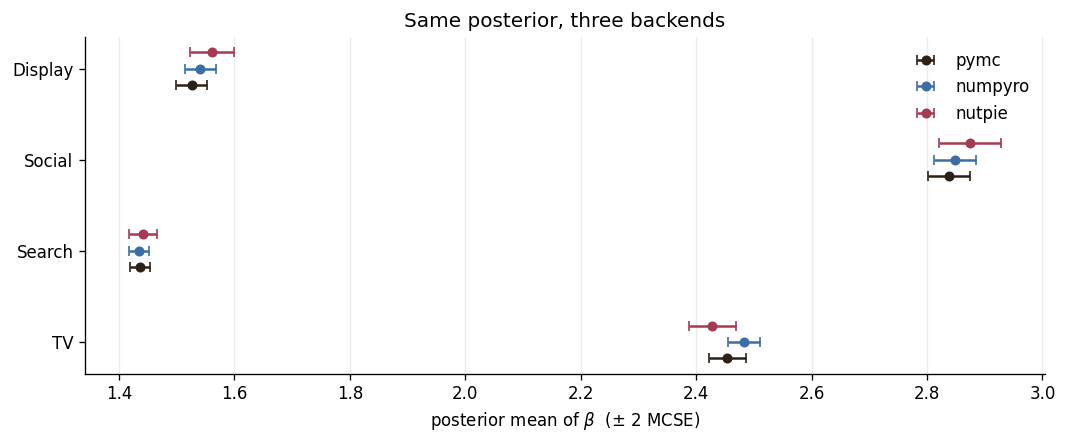

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.8))
off = {n: (i - (len(present) - 1) / 2) * 0.18 for i, n in enumerate(present)}
for name in present:
    ys = [i + off[name] for i in range(len(sc.channels))]
    ms = [betas[name][c][0] for c in sc.channels]
    es = [2 * betas[name][c][1] for c in sc.channels]   # +/- 2 MCSE
    ax.errorbar(ms, ys, xerr=es, fmt="o", ms=5, capsize=3,
                color=COLOR[name], label=name)
ax.set_yticks(range(len(sc.channels))); ax.set_yticklabels(sc.channels)
ax.set_xlabel(r"posterior mean of $\beta$  ($\pm$ 2 MCSE)")
ax.set_title("Same posterior, three backends"); ax.legend(frameon=False)
ax.grid(axis="y", visible=False); fig.tight_layout(); plt.show()

Overlapping intervals and small |z| are the expected — and required — result.
This is the cell to re-run first if you ever suspect a backend: a genuine
disagreement here is a bug in someone's sampler or in the graph's
compatibility with it, not a tuning question.

Note the error bars are **MCSE**, not posterior spread. They shrink as
`sqrt(ESS)` grows, so the backend with lower ESS/sec shows visibly wider bars at
equal draw counts — the cost of the efficiency difference, in the only units
that matter.

## 5 — Fixed cost vs marginal cost

Every backend pays a **fixed** cost (graph compilation, plus warmup) before it
produces a single kept draw, then a **marginal** cost per draw. A short
exploratory fit is dominated by the first; an overnight production fit by the
second. Ranking backends without separating them compares different things at
different scales.

Two draw counts at fixed `tune` give a two-point fit of
`time ≈ fixed + rate × draws`; the intercept absorbs compile *and* warmup.

In [8]:
SHORT = 250
short = {n: fit_once(sc, m, draws=SHORT, seed=0) for n, m, _ in BACKENDS}

cost = {}
for name, _, _ in BACKENDS:
    long_ok = [f for f in national[name] if f["ok"]]
    if not (short[name]["ok"] and long_ok):
        continue
    t_short, t_long = short[name]["secs"], float(np.median([f["secs"] for f in long_ok]))
    per_draw = (t_long - t_short) / (DRAWS - SHORT)
    cost[name] = {"t@250 s": t_short, "t@1000 s": t_long,
                  "ms / draw": 1000 * per_draw,
                  "fixed s": t_long - per_draw * DRAWS}
cdf = pd.DataFrame(cost).T
cdf["fixed %@1000"] = 100 * cdf["fixed s"] / cdf["t@1000 s"]
display(cdf.round(2))

,t@250 s,t@1000 s,ms / draw,fixed s,fixed %@1000
pymc,8.88,11.50,3.50,8.01,69.61
numpyro,8.40,10.12,2.29,7.83,77.35
nutpie,8.85,10.86,2.68,8.18,75.30


A large `fixed %` means the backend is being judged mostly on its compiler, not
its sampler. That flips the practical advice by use case: for a quick spec check
the low-fixed-cost backend wins even if its per-draw rate is worse, while for a
long production run only `ms / draw` matters.

Treat these as indicative — two points, one repeat at the short setting. A
careful version would sweep several draw counts and regress.

Note the 250-draw fits exist **only to time the intercept**; at that length the
chains are not converged (R-hat above the 1.01 bar), which is expected and
irrelevant here. Never read parameter estimates off a fit that short — §2–§4
use the full 1,000-draw runs for every number that matters.

## 6 — Does the ranking survive a bigger model?

Everything so far is one small national model (~150 rows, a handful of
parameters). Backends differ in *how they scale* — vectorised-chain and
compiled-gradient designs have overheads that only pay off past some size. So
the ranking from §3 is a fact about this model, not about the backends.

The geo panel is the same generative family across 8 regions with hierarchical
channel effects: ~8× the rows and a genuinely larger graph.

In [9]:
GEOS = ["North", "South", "East", "West", "Central", "Mountain", "Pacific", "Gulf"]
geo_sc = dgp_geo.make_geo_clean(seed=20, geos=GEOS)
geo = {}
for name, method, _ in BACKENDS:
    geo[name] = [fit_once(geo_sc, method, seed=0)]
    f = geo[name][0]
    print(f"{name:9} " + (f"{f['secs']:6.1f}s  ESS/s={f['ess_per_s']:6.1f}"
                          if f["ok"] else f"FAILED: {f['error']}"))

geo_eff = pd.DataFrame({
    n: {"secs": runs[0]["secs"], "min ESS": runs[0]["ess_min"],
        "ESS/sec": runs[0]["ess_per_s"], "R-hat max": runs[0]["rhat"],
        "divergences": runs[0]["div"]}
    for n, runs in geo.items() if runs[0]["ok"]}).T
display(geo_eff.round({"secs": 1, "min ESS": 0, "ESS/sec": 1,
                       "R-hat max": 4, "divergences": 0}))

pymc        68.7s  ESS/s=  28.3


numpyro     57.4s  ESS/s=  45.5


nutpie      55.9s  ESS/s=  35.6


,secs,min ESS,ESS/sec,R-hat max,divergences
pymc,68.7,1946.0,28.3,1.0038,0.0
numpyro,57.4,2612.0,45.5,1.0039,0.0
nutpie,55.9,1988.0,35.6,1.0050,0.0


,national ESS/s,geo ESS/s,national rank,geo rank
pymc,196.9,28.3,1,3
numpyro,179.7,45.5,2,1
nutpie,105.1,35.6,3,2


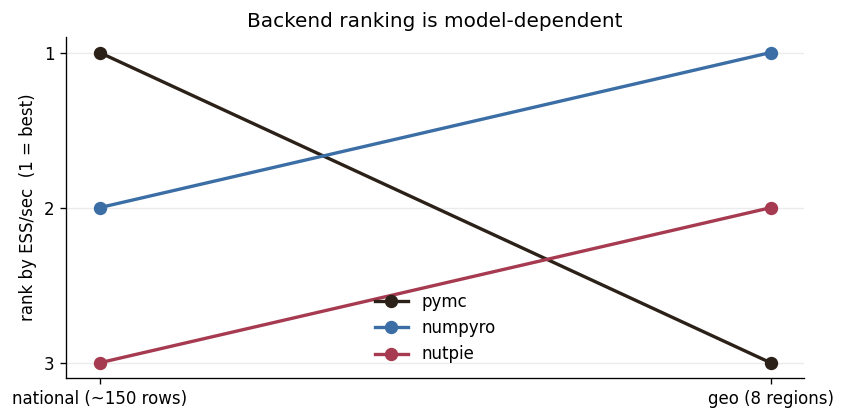

In [10]:
common = [n for n in eff.index if n in geo_eff.index]
rel = pd.DataFrame({
    "national ESS/s": eff.loc[common, "ESS/sec"],
    "geo ESS/s": geo_eff.loc[common, "ESS/sec"],
})
rel["national rank"] = rel["national ESS/s"].rank(ascending=False).astype(int)
rel["geo rank"] = rel["geo ESS/s"].rank(ascending=False).astype(int)
display(rel.round(1))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
for n in common:
    ax.plot([0, 1], [rel.loc[n, "national rank"], rel.loc[n, "geo rank"]],
            "o-", color=COLOR[n], label=n, lw=2, ms=7)
ax.set_xticks([0, 1]); ax.set_xticklabels(["national (~150 rows)", f"geo ({len(GEOS)} regions)"])
ax.set_yticks(range(1, len(common) + 1)); ax.invert_yaxis()
ax.set_ylabel("rank by ESS/sec  (1 = best)")
ax.set_title("Backend ranking is model-dependent")
ax.legend(frameon=False); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

If the lines cross, the ranking inverted with model size — which is the whole
lesson. **Benchmark on your model, at your size.** A backend recommendation
that does not name the model it was measured on is not information.

Two caveats on this section, stated rather than buried: it is one repeat per
backend (the geo fits are slow), and one machine. Rank *changes* are the signal;
small ESS/s differences are not.

## 7 — `target_accept`, which now reaches the sampler

`target_accept` is the first knob the
[sampling-failure playbook](../../technical-docs/sampling-failure-playbook.md)
tells you to raise when you see divergences: a higher target forces smaller
steps, which navigate tight posterior geometry at the cost of time.

**Through v1.1.0, setting it on the config did nothing.** `fit()` ignored
`ModelConfig.target_accept` and used a literal `0.9`, so
`ModelConfigBuilder().with_target_accept(0.95)` was a silent no-op — the fix
shipped in v1.2.0. Here is the evidence it now takes effect: as the target
rises, the adapted **step size** must fall and the realised acceptance rate must
track the target. Before the fix all three rows below were identical.

In [11]:
ta_rows = []
for ta in (0.80, 0.90, 0.99):
    f = fit_once(sc, InferenceMethod.BAYESIAN_PYMC, draws=500, tune=500,
                 seed=0, target_accept=ta)
    if not f["ok"]:
        ta_rows.append({"target_accept": ta, "error": f["error"]}); continue
    ss = f["trace"].sample_stats
    ta_rows.append({
        "target_accept": ta,
        "realised accept": float(ss["acceptance_rate"].mean()),
        "step size": float(ss["step_size"].mean()),
        "steps / draw": float(ss["n_steps"].mean()),
        "secs": f["secs"], "divergences": f["div"],
    })
display(pd.DataFrame(ta_rows).round(4))

,target_accept,realised accept,step size,steps / draw,secs,divergences
0,0.80,0.8764,0.0732,59.496,6.9159,0
1,0.90,0.9155,0.0592,64.952,7.9376,0
2,0.99,0.9865,0.0271,149.768,12.0339,0


Step size falls and steps-per-draw rises as the target increases — the sampler
is taking smaller, more careful steps, and paying for them in gradient
evaluations. That is the trade you are buying when you raise it.

On this clean world there are **no divergences to fix**, so raising the target
only costs time. That is the honest demonstration: the knob works, and on a
healthy model it buys nothing. Reach for it when you *have* divergences.

> **Backend portability gotcha.** The cell above reads `acceptance_rate` and
> `n_steps` from `sample_stats` — keys the `pymc` and `numpyro` backends
> provide but **`nutpie` does not** (it reports `mean_tree_accept` and `depth`
> instead). Sampler statistics are *not* a portable schema across backends.
> The one key all three agree on is **`diverging`**, which is what every
> divergence check in this framework reads — so switching backend never
> silently breaks divergence reporting.

## 8 — What about `frequentist_ridge`?

`InferenceMethod` has two non-Bayesian entries, `FREQUENTIST_RIDGE` and
`FREQUENTIST_CVXPY`, with builder methods advertising "Ridge regression (fast,
frequentist)" and "CVXPY for constrained optimization".

**Neither is implemented.** They are declared enum values with builder setters
and nothing that consumes them: `fit()` dispatches on `FitMethod`
(`nuts`/`smc`/`map`/`advi`/`laplace`/`pathfinder`), never on `InferenceMethod`,
and the package depends on neither `scikit-learn` nor `cvxpy`. Selecting one
does not raise — it silently fits **full Bayesian NUTS** via the `"pymc"`
fallback in `ModelConfig.nuts_sampler`.

In [12]:
ridge_cfg = ModelConfig(inference_method=InferenceMethod.FREQUENTIST_RIDGE)
print(f"inference_method : {ridge_cfg.inference_method.value}")
print(f"is_bayesian      : {ridge_cfg.is_bayesian}      <- correctly False ...")
print(f"nuts_sampler     : {ridge_cfg.nuts_sampler!r}   <- ... but still routes to NUTS")
print(f"fit_method       : {ridge_cfg.fit_method.value}  <- what fit() actually dispatches on")
print()
print("No ridge/cvxpy implementation exists:")
for mod in ("sklearn", "cvxpy"):
    try:
        __import__(mod); print(f"  {mod:8} importable, but nothing in mmm_framework uses it")
    except ImportError:
        print(f"  {mod:8} not installed - not a dependency of this package")

inference_method : frequentist_ridge
is_bayesian      : False      <- correctly False ...
nuts_sampler     : 'pymc'   <- ... but still routes to NUTS
fit_method       : nuts  <- what fit() actually dispatches on

No ridge/cvxpy implementation exists:
  sklearn  not installed - not a dependency of this package
  cvxpy    not installed - not a dependency of this package


If you want a fast frequentist point estimate for spec exploration, the
supported route is the **approximate tier on the fit-method axis** —
`fit(method="map")` gives a penalised point estimate in seconds (the priors act
as the penalty, which is what ridge *is*), and
[`approximate_posteriors.ipynb`](approximate_posteriors.ipynb) compares the
whole tier. Do not reach for `frequentist_ridge`; it does not do what its name
says.

## 9 — What to take away

1. **The backend does not change the answer.** All three are exact samplers on
   one posterior and agreed within Monte Carlo error (§4). If yours disagree,
   that is a bug, not a preference.
2. **Wall-clock cannot rank them** (§2) — repeat-to-repeat spread swamps the
   difference. Use **ESS/second**, on your worst-mixing parameter (§3).
3. **The ranking is model-dependent** (§6). It changed between a small national
   model and a geo panel *in this notebook*. Any claim that one backend is
   "the fastest", including one in a docstring, is incomplete without the model
   it was measured on.
4. **Separate fixed from marginal cost** (§5) before choosing for a workload:
   compile-dominated short fits and draw-dominated long fits want different
   backends.
5. **Sampler statistics are not portable** (§7). Only `diverging` is common to
   all three.

### How to run this on your own model

Swap the world for your panel and keep everything else:

```python
model = BayesianMMM(your_panel, cfg, trend_cfg)   # cfg per backend, as above
```

Run §2–§4 at your real draw count. The decision rule is: whichever backend
gives the highest **min-ESS per second** while agreeing with the others in §4,
at the size you actually fit. Re-measure when your model changes materially —
adding a geo hierarchy is exactly the kind of change that moves it.

> Reproduce or extend: swap `dgp.make_clean` for a harder world
> (`dgp.make_realistic`, or the violation scenarios in `mmm_framework.synth`)
> to see whether a difficult posterior separates the backends more sharply than
> a clean one does.